In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [43]:
df = pd.read_csv("../data/train.csv")
df = df.drop("Loan_ID", axis=1)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [44]:
df.shape

(614, 12)

In [45]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [46]:
df.info

<bound method DataFrame.info of      Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0      Male      No          0      Graduate            No             5849   
1      Male     Yes          1      Graduate            No             4583   
2      Male     Yes          0      Graduate           Yes             3000   
3      Male     Yes          0  Not Graduate            No             2583   
4      Male      No          0      Graduate            No             6000   
..      ...     ...        ...           ...           ...              ...   
609  Female      No          0      Graduate            No             2900   
610    Male     Yes         3+      Graduate            No             4106   
611    Male     Yes          1      Graduate            No             8072   
612    Male     Yes          2      Graduate            No             7583   
613  Female      No          0      Graduate           Yes             4583   

     CoapplicantInc

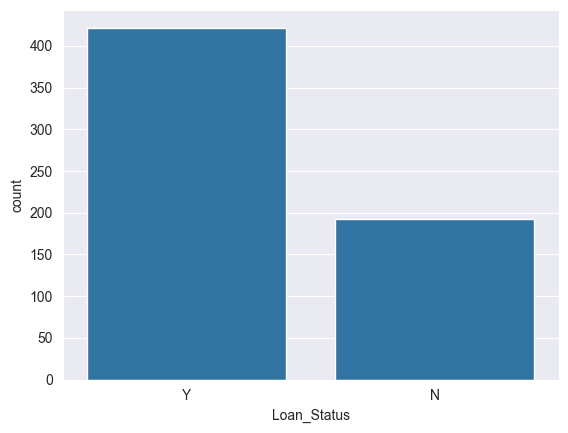

In [47]:
sns.countplot(x="Loan_Status", data = df)
plt.show()

In [48]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [49]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [50]:
for col in ["Gender", "Married", "Dependents", "Self_Employed"]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [51]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [52]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [53]:
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df["Income_Loan_Ratio"] = df["Total_Income"]/df["LoanAmount"]

In [54]:
df = pd.get_dummies(df, drop_first=True)

In [55]:
X = df.drop("Loan_Status_Y", axis=1)
y = df["Loan_Status_Y"]

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scale, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [59]:
print(model.n_iter_)

[12]


In [60]:
y_pred = model.predict(X_test_scale)

Accuracy:  0.7804878048780488


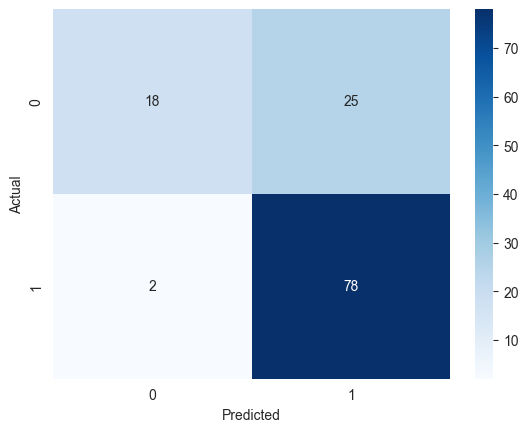

              precision    recall  f1-score   support

       False       0.90      0.42      0.57        43
        True       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred))

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model = rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

RandomForest Accuracy 0.8048780487804879
              precision    recall  f1-score   support

       False       0.85      0.53      0.66        43
        True       0.79      0.95      0.86        80

    accuracy                           0.80       123
   macro avg       0.82      0.74      0.76       123
weighted avg       0.81      0.80      0.79       123



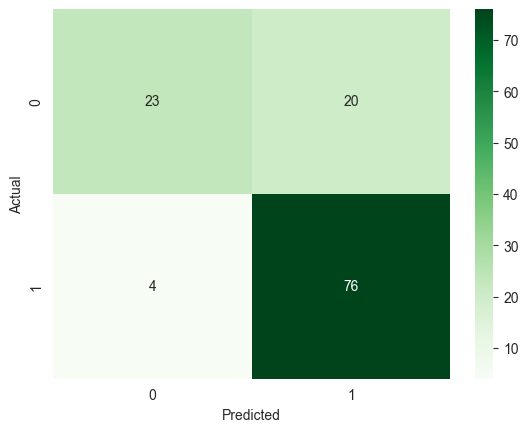

In [63]:
print("RandomForest Accuracy", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

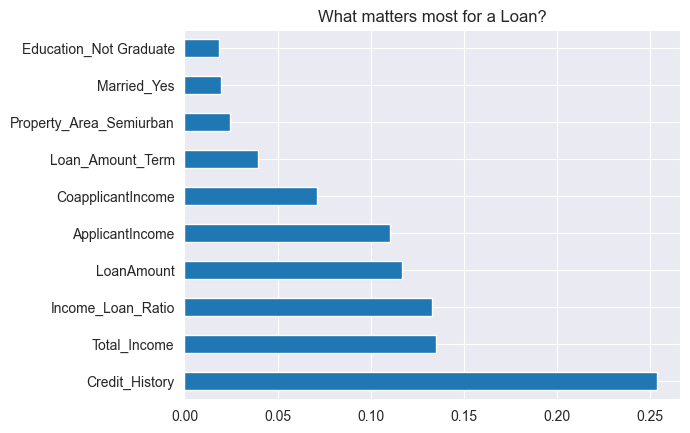

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the importance of each feature
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort and plot them
importances.nlargest(10).plot(kind='barh')
plt.title("What matters most for a Loan?")
plt.show()


In [65]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100, 200,300],
    'max_depth' : [None, 5, 10],
    'min_samples_split' : [2, 5],
    'min_samples_leaf' : [1, 2]
}
rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv = 5, scoring='accuracy')
grid.fit(X_train, y_train)
print("Best Parameters: ", grid.best_params_)

best_rf = grid.best_estimator_
rf_tuned_pred = best_rf.predict(X_test)
print("Tuned RF Accuracy: ", accuracy_score(y_test, rf_tuned_pred))
print(classification_report(y_test, rf_tuned_pred))

Best Parameters:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Tuned RF Accuracy:  0.7886178861788617
              precision    recall  f1-score   support

       False       0.81      0.51      0.63        43
        True       0.78      0.94      0.85        80

    accuracy                           0.79       123
   macro avg       0.80      0.72      0.74       123
weighted avg       0.79      0.79      0.77       123



                    Feature  Importance
4            Credit_History    0.359417
6         Income_Loan_Ratio    0.132674
5              Total_Income    0.116059
2                LoanAmount    0.094479
0           ApplicantIncome    0.088290
1         CoapplicantIncome    0.059811
3          Loan_Amount_Term    0.037145
14  Property_Area_Semiurban    0.027507
8               Married_Yes    0.019320
12   Education_Not Graduate    0.012650
9              Dependents_1    0.011923
15      Property_Area_Urban    0.010678
7               Gender_Male    0.010273
10             Dependents_2    0.007906
13        Self_Employed_Yes    0.007186
11            Dependents_3+    0.004680


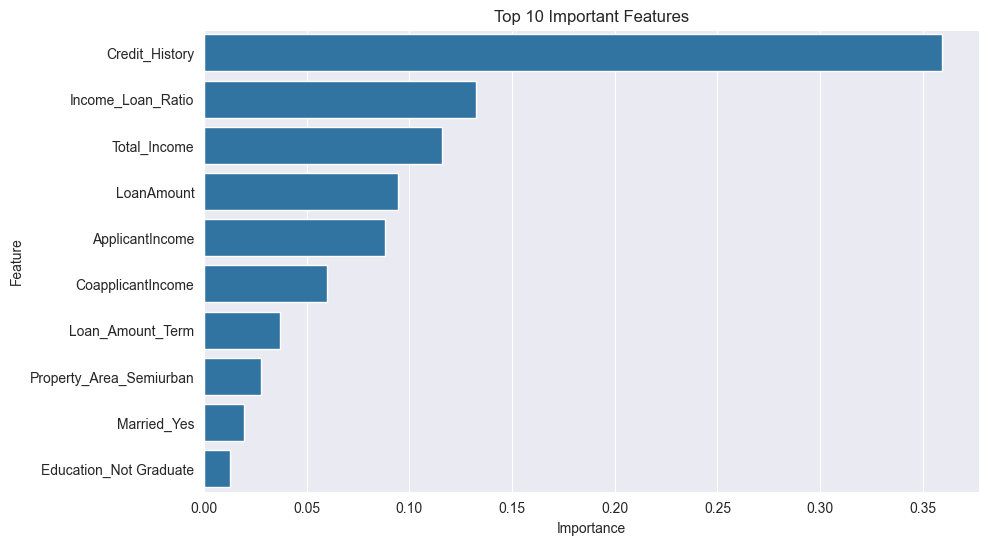

In [66]:
import seaborn as sns
feature_importances = best_rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({
    'Feature' : features,
    'Importance' : feature_importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)
plt.figure(figsize=(10,6))
sns.barplot(x = 'Importance', y = 'Feature', data=importance_df.head(10))
plt.title('Top 10 Important Features')
plt.show()

In [67]:
import joblib

joblib.dump(best_rf, "../models/loan_model.pkl")

['../models/loan_model.pkl']

In [68]:
loaded_model = joblib.load("../models/loan_model.pkl")

pred = loaded_model.predict(X_test)

print("Loaded Model Accuracy:", accuracy_score(y_test, pred))

Loaded Model Accuracy: 0.7886178861788617
